# Лабораторная работа 4. Сопряженные направления и методы Ньютона

## Цель работы

Реализовать и сравнить методы второго порядка и методы сопряженных направлений: линейный метод сопряженных градиентов, нелинейные CG (Флетчера-Ривса и Полака-Рибьера), метод Ньютона с разложением Холецкого, модифицированный Ньютон, Powell's Dog Leg и квазиньютоновские DFP, BFGS, L-BFGS (плюс готовый `scipy` Newton-CG). Все методы имеют единый интерфейс и считают число итераций и вызовов функции (nf), градиента (ng) и матрицы Гессе (nh). Тестируем на генераторе выпуклых квадратичных функций (с заданными размерностью `n` и обусловленностью `k`) и на сложных функциях.

Критерий остановки везде: `‖∇f(x)‖ ≤ ε`, `ε = 1e-8`. Реализация методов - в `optimizers.py`, функции и генератор - в `functions.py`.

## Описание методов

Все методы строят шаг `x ← x + α·p`; различаются выбором направления `p` и шага `α`.

- **CG (линейный)** - для квадратичной `f = ½⟨x,Ax⟩ − ⟨b,x⟩`. Строит сопряженные относительно `A` направления; на точной арифметике сходится не более чем за `n` шагов. Использует только умножения на `A`.
- **Нелинейный CG (FR / PR)** - обобщение CG на произвольные функции. Направление `p ← −g + β·p`, где `β` по формуле Флетчера-Ривса `βᶠᴿ = (gₖ₊₁·gₖ₊₁)/(gₖ·gₖ)` или Полака-Рибьера `βᴾᴿ = max(0, gₖ₊₁·(gₖ₊₁−gₖ)/(gₖ·gₖ))`. Шаг - по сильным условиям Вольфе, рестарт каждые `n` шагов.
- **Ньютон (Холецкий)** - решает `H·p = −g` через разложение Холецкого `H = LLᵀ` (двумя треугольными проходами), шаг `α = 1`. Если `H` не положительно определена, Холецкий падает → метод останавливается со статусом `not_pd`.
- **Модифицированный Ньютон** - направление `p = −H⁻¹g`, если `H ≻ 0`, иначе откат к `p = −g`; длина шага подбирается одномерным поиском (Вольфе). Так метод не ломается на неопределенной `H`.
- **Powell's Dog Leg** - метод доверительной области. Шаг ищется как ломаная: точка Коши `pᵁ` (вдоль антиградиента) → ньютоновский шаг `pᴺ`. Радиус `Δ` меняется по отношению фактического и предсказанного убывания `ρ`.
- **DFP / BFGS** - квазиньютоновские: хранят приближение обратного гессиана `G` и обновляют его по секущему условию `G·y = s` (`s = Δx`, `y = Δg`), не вычисляя `H`. Направление `p = −G·g`.
- **L-BFGS** - BFGS с ограниченной памятью: хранит последние `m` пар `(s, y)`, направление считается двухцикловой рекурсией за `O(mn)`. Подходит для больших `n`.
- **Newton-CG** - готовый `scipy.optimize.minimize(method="Newton-CG")` для сравнения.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import functions as F
import optimizers as O

## Вспомогательные функции (запуск, таблицы, графики)

In [2]:
TOL = 1e-8
MI = 1000

METHODS = [
    ("CG-lin", O.cg_linear, {}, True),
    ("NCG-FR", O.nonlinear_cg, dict(variant="FR"), False),
    ("NCG-PR", O.nonlinear_cg, dict(variant="PR"), False),
    ("Newton", O.newton_cholesky, {}, False),
    ("Newton-mod", O.newton_modified, {}, False),
    ("DogLeg", O.dogleg, {}, False),
    ("DFP", O.quasi_newton, dict(variant="DFP"), False),
    ("BFGS", O.quasi_newton, dict(variant="BFGS"), False),
    ("L-BFGS", O.lbfgs, dict(m=10), False),
    ("Newton-CG", O.newton_cg_scipy, {}, False),
]

def run_all(prob, x0, quad=False):
    out = {}
    for name, func, kw, quad_only in METHODS:
        if quad_only and not quad:
            continue
        out[name] = O.run(func, prob, x0, tol=TOL, max_iter=MI, **kw)
    return out

def fnum(v, d=4):
    return f"{v:.{d}g}"

def print_table(title, headers, rows):
    print("\n" + title)
    cols = list(zip(*([headers] + rows)))
    w = [max(len(str(c)) for c in col) for col in cols]
    def fmt(r):
        return " | ".join(str(c).ljust(w[i]) for i, c in enumerate(r))
    print(fmt(headers))
    print("-+-".join("-" * x for x in w))
    for r in rows:
        print(fmt(r))

def metric_plot(title, xlabel, xvals, series, logx=False):
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, ys in series:
        ax.plot(xvals, ys, "-o", label=label, markersize=4)
    ax.set_xlabel(xlabel); ax.set_ylabel("число итераций")
    ax.set_title(title); ax.set_yscale("log")
    if logx:
        ax.set_xscale("log")
    ax.grid(True, which="both", linewidth=0.3)
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()

def _subsample(traj, maxpts=800):
    if len(traj) > maxpts:
        idx = np.linspace(0, len(traj) - 1, maxpts).astype(int)
        return traj[idx]
    return traj

def traj_grid(suptitle, Zfun, xlim, ylim, levels, mins, per_method, ncols=5):
    names = list(per_method.keys())
    nrows = int(np.ceil(len(names) / ncols))
    xs = np.linspace(xlim[0], xlim[1], 300)
    ys = np.linspace(ylim[0], ylim[1], 300)
    X, Y = np.meshgrid(xs, ys)
    Z = Zfun(X, Y)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, name in zip(axes, names):
        ax.axis("on")
        ax.contour(X, Y, Z, levels=levels, cmap="Greys", linewidths=0.4)
        for lbl, traj in per_method[name]:
            t = _subsample(traj)
            ax.plot(t[:, 0], t[:, 1], "-", linewidth=0.9)
            ax.plot(t[0, 0], t[0, 1], "o", markersize=3, color="green")
        for mpt in mins:
            ax.plot(mpt[0], mpt[1], "r*", markersize=9)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_title(name, fontsize=9)
    fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()

## Пункт 1

Генератор квадратичных функций: зависимость методов от размерности `n` и обусловленности `k`. Таблицы числа итераций и вызовов градиента + графики зависимости от `n` (при фиксированном `k`) и от `k` (при фиксированном `n`). `*` в таблице = метод не достиг точности 1e-8.


Число итераций, k=100 (* = не достигнута точность 1e-8)
метод      | n=2 | n=10 | n=50 | n=100
-----------+-----+------+------+------
CG-lin     | 2   | 11   | 61   | 86   
NCG-FR     | 30* | 72*  | 96*  | 97*  
NCG-PR     | 25* | 92*  | 92*  | 91*  
Newton     | 1   | 1    | 1    | 1    
Newton-mod | 1   | 1    | 1    | 1    
DogLeg     | 2   | 3    | 4    | 4    
DFP        | 3   | 17*  | 54*  | 82*  
BFGS       | 4   | 21*  | 57*  | 85*  
L-BFGS     | 7   | 42*  | 84*  | 88*  
Newton-CG  | 3   | 12   | 14*  | 18   

Число итераций, n=50
метод      | k=1 | k=10 | k=100 | k=1000
-----------+-----+------+-------+-------
CG-lin     | 1   | 29   | 61    | 103   
NCG-FR     | 1   | 34*  | 96*   | 273*  
NCG-PR     | 1   | 29*  | 92*   | 283*  
Newton     | 1   | 1    | 1     | 1     
Newton-mod | 1   | 1    | 1     | 1     
DogLeg     | 4   | 4    | 4     | 4     
DFP        | 1   | 39*  | 54*   | 61*   
BFGS       | 1   | 46*  | 57*   | 62*   
L-BFGS     | 1   | 29*  | 84*   | 222*  
Ne

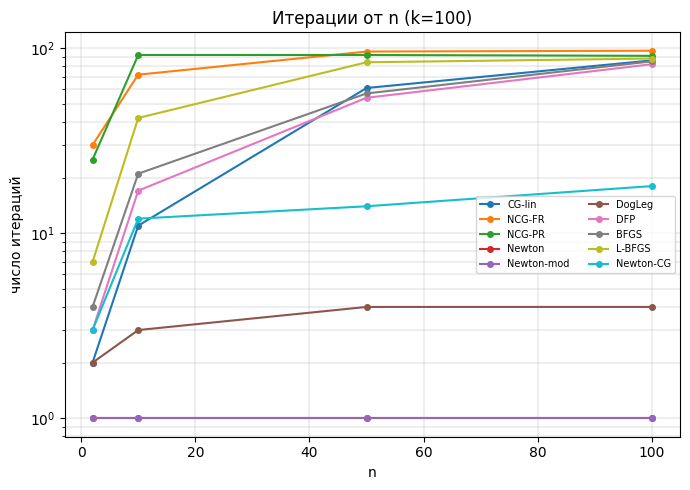

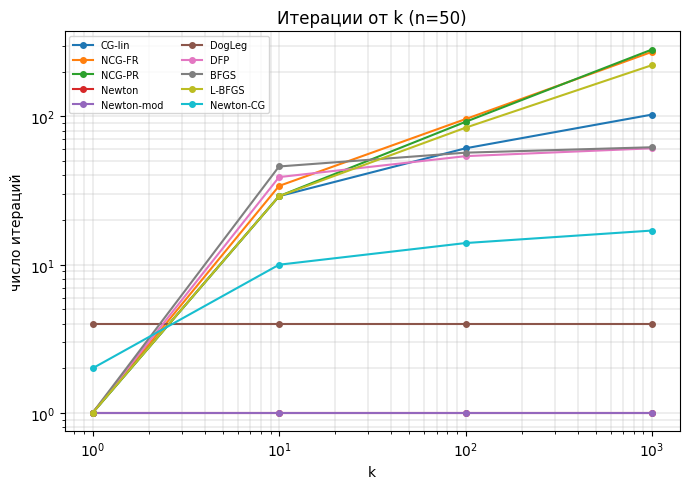

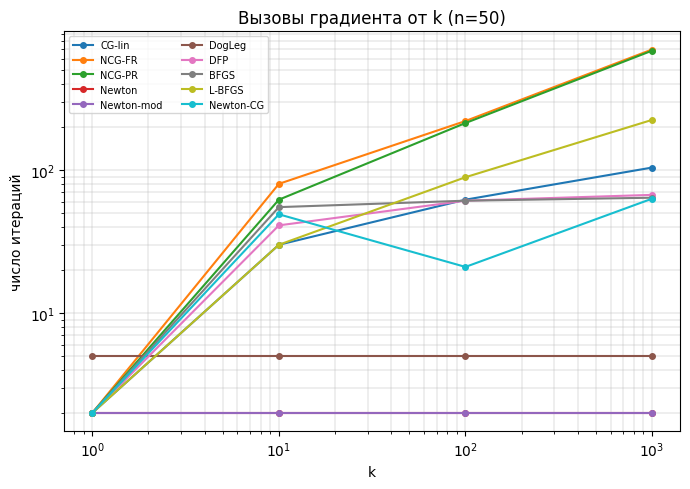

In [3]:
ns = [2, 10, 50, 100]
ks = [1, 10, 100, 1000]
grid = {}
for n in ns:
    for k in ks:
        prob = F.make_quadratic(n, k, seed=0)
        x0 = prob.x_star + 1.0
        grid[(n, k)] = run_all(prob, x0, quad=True)
mnames = [m[0] for m in METHODS]

def cell(res):
    return f"{res['iters']}" + ("" if res["converged"] else "*")

k0 = 100
rows = [[name] + [cell(grid[(n, k0)][name]) for n in ns] for name in mnames]
print_table(f"Число итераций, k={k0} (* = не достигнута точность 1e-8)",
            ["метод"] + [f"n={n}" for n in ns], rows)
n0 = 50
rows = [[name] + [cell(grid[(n0, k)][name]) for k in ks] for name in mnames]
print_table(f"Число итераций, n={n0}", ["метод"] + [f"k={k}" for k in ks], rows)
rows = [[name] + [grid[(n0, k)][name]["ng"] for k in ks] for name in mnames]
print_table(f"Вызовы градиента (ng), n={n0}", ["метод"] + [f"k={k}" for k in ks], rows)

metric_plot(f"Итерации от n (k={k0})", "n", ns,
            [(name, [grid[(n, k0)][name]["iters"] for n in ns]) for name in mnames])
metric_plot(f"Итерации от k (n={n0})", "k", ks,
            [(name, [grid[(n0, k)][name]["iters"] for k in ks]) for name in mnames], logx=True)
metric_plot(f"Вызовы градиента от k (n={n0})", "k", ks,
            [(name, [grid[(n0, k)][name]["ng"] for k in ks]) for name in mnames], logx=True)

## Пункт 2

Двумерная квадратичная (`n=2`, `k=10`): запуск всех методов из 5 стартовых точек, таблица числа итераций и траектории на линиях уровня (зеленая точка - старт, красная звезда - минимум).


Число итераций по стартам
старт              | CG-lin | NCG-FR | NCG-PR | Newton | Newton-mod | DogLeg | DFP | BFGS | L-BFGS | Newton-CG
-------------------+--------+--------+--------+--------+------------+--------+-----+------+--------+----------
s0=(2.464,3.362)   | 2      | 17     | 20     | 1      | 1          | 3      | 4   | 5    | 10     | 3        
s1=(-4.536,2.362)  | 2      | 24     | 19     | 1      | 1          | 3      | 3   | 4    | 6      | 5        
s2=(4.464,-0.6384) | 2      | 15     | 17     | 1      | 1          | 3      | 2   | 2    | 4      | 4        
s3=(-2.536,-4.638) | 2      | 20     | 19     | 1      | 1          | 3      | 3   | 4    | 4      | 4        
s4=(0.4643,6.362)  | 2      | 24     | 19     | 1      | 1          | 3      | 7   | 7    | 7      | 2        


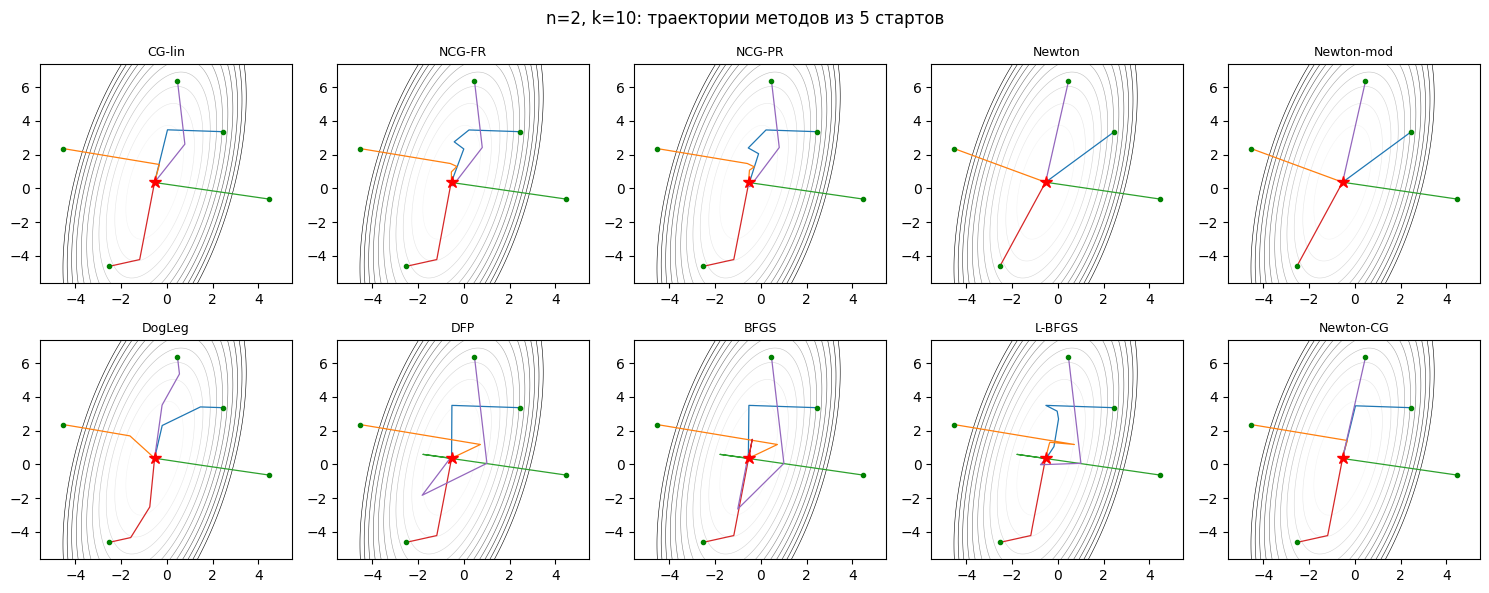

In [4]:
prob = F.make_quadratic(2, 10, seed=0)
xs = prob.x_star
starts = [xs + d for d in [np.array([3., 3.]), np.array([-4., 2.]),
                           np.array([5., -1.]), np.array([-2., -5.]), np.array([1., 6.])]]
A, b = prob.A, prob.b

def Z(X, Y):
    return 0.5 * (A[0, 0] * X ** 2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y ** 2) - b[0] * X - b[1] * Y

allpts = np.array(starts + [xs])
pad = 1.0
xlim = (allpts[:, 0].min() - pad, allpts[:, 0].max() + pad)
ylim = (allpts[:, 1].min() - pad, allpts[:, 1].max() + pad)
levels = prob._f(xs) + np.linspace(0.5, 60, 12)

mnames = [m[0] for m in METHODS]
per_method = {name: [] for name in mnames}
table_rows = []
for si, s in enumerate(starts):
    res = run_all(prob, s, quad=True)
    for name in mnames:
        per_method[name].append((f"s{si}", res[name]["traj"]))
    table_rows.append([f"s{si}=({fnum(s[0])},{fnum(s[1])})"] + [res[name]["iters"] for name in mnames])
print_table("Число итераций по стартам", ["старт"] + mnames, table_rows)
traj_grid("n=2, k=10: траектории методов из 5 стартов", Z, xlim, ylim, levels, [tuple(xs)], per_method)

## Пункт 3

Сложные функции (Розенброка и Химмельблау): запуск из нескольких стартов. Таблица с найденной точкой, значением `f`, нормой градиента, числом итераций и статусом остановки + траектории. `CG-lin` тут не участвует (он только для квадратичных).


Функция Розенброка: результаты по стартам
метод      | старт       | найдено         | f         | ||grad|| | итер | статус  
-----------+-------------+-----------------+-----------+----------+------+---------
NCG-FR     | (-1.2,1.0)  | (1,1)           | 6.207e-19 | 7.6e-10  | 473  | grad    
NCG-PR     | (-1.2,1.0)  | (1,1)           | 3.112e-17 | 5.0e-09  | 40   | grad    
Newton     | (-1.2,1.0)  | (1,1)           | 3.433e-20 | 8.3e-09  | 6    | grad    
Newton-mod | (-1.2,1.0)  | (1,1)           | 7.682e-24 | 1.2e-10  | 21   | grad    
DogLeg     | (-1.2,1.0)  | (1,1)           | 8.589e-22 | 1.3e-09  | 24   | grad    
DFP        | (-1.2,1.0)  | (1,1)           | 2.733e-19 | 9.8e-09  | 37   | grad    
BFGS       | (-1.2,1.0)  | (1,1)           | 1.688e-22 | 5.8e-10  | 35   | grad    
L-BFGS     | (-1.2,1.0)  | (1,1)           | 9.092e-22 | 1.3e-09  | 37   | grad    
Newton-CG  | (-1.2,1.0)  | (1,1)           | 1.317e-19 | 3.2e-10  | 85   | grad    
NCG-FR     | (2.0,2.0)   | (1,1) 

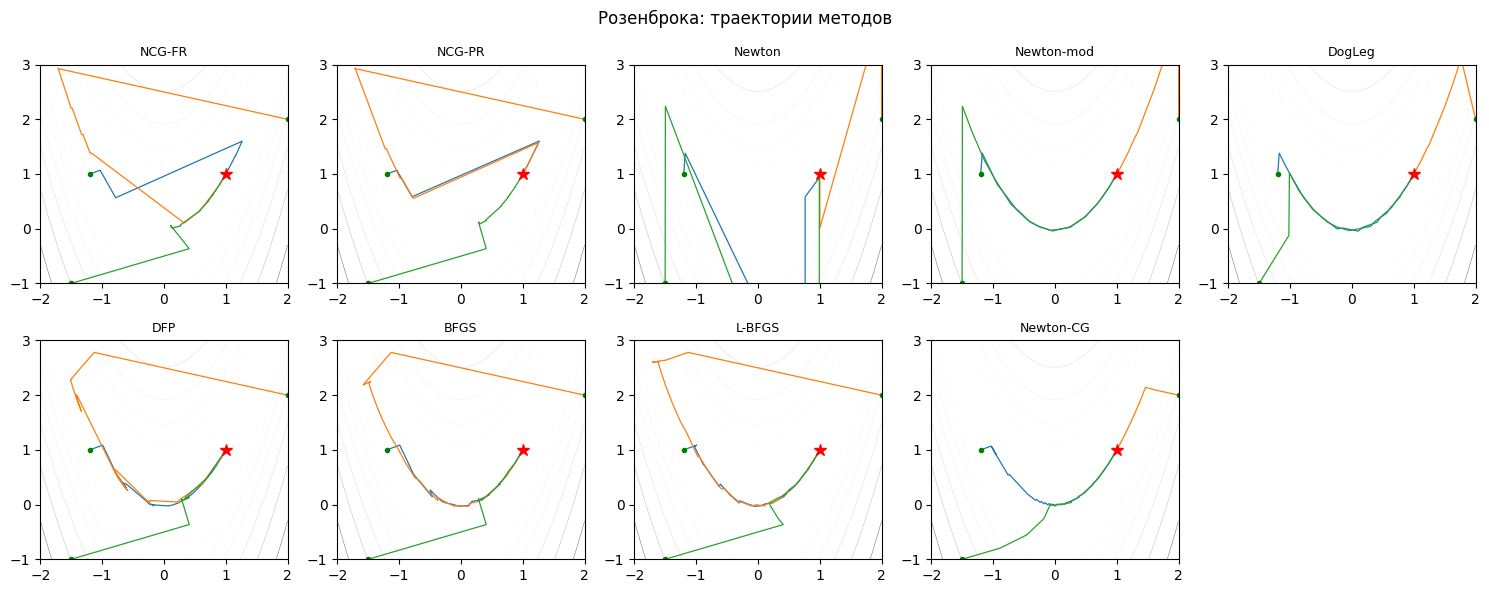


Функция Химмельблау: результаты по стартам
метод      | старт       | найдено         | f         | ||grad|| | итер | статус
-----------+-------------+-----------------+-----------+----------+------+-------
NCG-FR     | (0.0,0.0)   | (3,2)           | 1.018e-18 | 7.4e-09  | 17   | grad  
NCG-PR     | (0.0,0.0)   | (3,2)           | 5.343e-19 | 8.9e-09  | 22   | grad  
Newton     | (0.0,0.0)   | (0,0)           | 170       | 2.6e+01  | 0    | not_pd
Newton-mod | (0.0,0.0)   | (3,2)           | 0         | 0.0e+00  | 7    | grad  
DogLeg     | (0.0,0.0)   | (3,2)           | 1.975e-27 | 5.3e-13  | 9    | grad  
DFP        | (0.0,0.0)   | (3,2)           | 1.238e-19 | 4.0e-09  | 11   | grad  
BFGS       | (0.0,0.0)   | (3,2)           | 1.428e-19 | 3.8e-09  | 10   | grad  
L-BFGS     | (0.0,0.0)   | (3,2)           | 6.181e-20 | 1.8e-09  | 11   | grad  
Newton-CG  | (0.0,0.0)   | (3,2)           | 4.355e-24 | 1.6e-11  | 9    | grad  
NCG-FR     | (-3.0,3.0)  | (-2.805,3.131)  | 2.155e-21

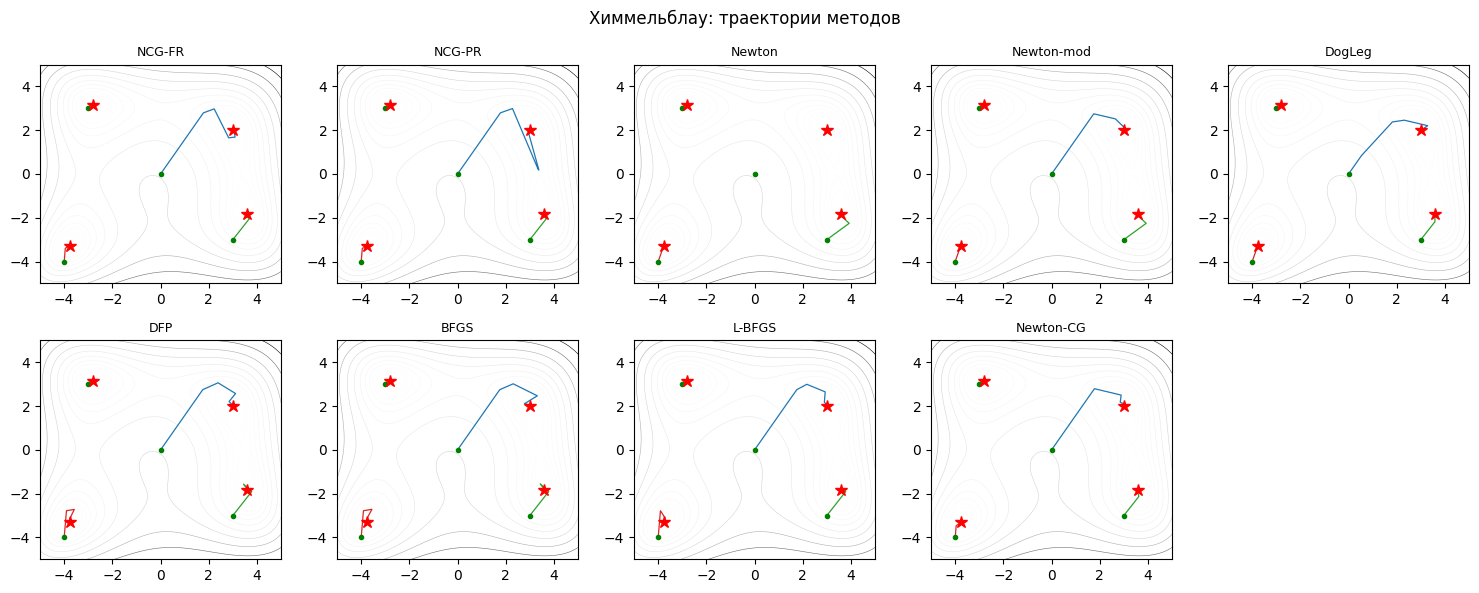

In [5]:
cfgs = [
    ("rosen", F.make_rosenbrock, [(-1.2, 1.0), (2.0, 2.0), (-1.5, -1.0)],
     (lambda X, Y: (1 - X) ** 2 + 100 * (Y - X ** 2) ** 2),
     (-2, 2), (-1, 3), np.logspace(0, 3.5, 16), [(1, 1)]),
    ("himmel", F.make_himmelblau, [(0., 0.), (-3., 3.), (3., -3.), (-4., -4.)],
     (lambda X, Y: (X ** 2 + Y - 11) ** 2 + (X + Y ** 2 - 7) ** 2),
     (-5, 5), (-5, 5), np.logspace(0, 2.8, 16),
     [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]),
]
mnames = [m[0] for m in METHODS if m[0] != "CG-lin"]
for key, factory, starts, Z, xlim, ylim, levels, mins in cfgs:
    prob = factory()
    per_method = {name: [] for name in mnames}
    rows = []
    for s in starts:
        res = run_all(prob, s, quad=False)
        for name in mnames:
            r = res[name]
            per_method[name].append((str(s), r["traj"]))
            gn = np.linalg.norm(prob._grad(np.asarray(r["x"], float)))
            rows.append([name, f"({s[0]},{s[1]})",
                         f"({fnum(r['x'][0])},{fnum(r['x'][1])})", fnum(r["fx"]),
                         f"{gn:.1e}", r["iters"], r["status"]])
    print_table(f"Функция {prob.name}: результаты по стартам",
                ["метод", "старт", "найдено", "f", "||grad||", "итер", "статус"], rows)
    traj_grid(f"{prob.name}: траектории методов", Z, xlim, ylim, levels, mins, per_method)

## Пункт 4

Память `m` в L-BFGS и сравнение суммарной стоимости методов. Сначала L-BFGS с разной памятью `m` на трудной задаче (`n=50`, `k=1000`), затем таблица стоимости всех методов на `n=50`, `k=100` (грубая оценка `cost = nf + ng + n·nh`, считая вычисление Гессе примерно как `n` градиентов).


L-BFGS: влияние памяти m (n=50, k=1000)
m  | итераций | сошелся | ||x-x*|| | статус     
---+----------+---------+----------+------------
1  | 344      | нет     | 3.4e-06  | no_progress
2  | 265      | нет     | 7.3e-06  | no_progress
5  | 239      | нет     | 3.1e-06  | no_progress
10 | 222      | нет     | 2.4e-06  | no_progress
20 | 197      | нет     | 3.3e-06  | no_progress
50 | 139      | нет     | 2.8e-06  | no_progress


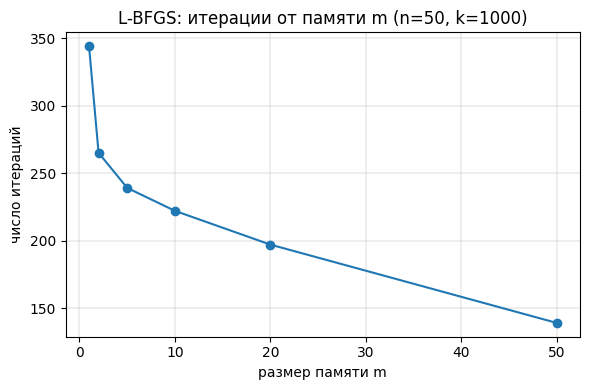


Стоимость на квадратичной n=50, k=100 (cost = nf+ng+n*nh)
метод      | итер | nf  | ng  | nh | cost | сош.
-----------+------+-----+-----+----+------+-----
CG-lin     | 61   | 0   | 62  | 0  | 62   | да  
NCG-FR     | 96   | 944 | 220 | 0  | 1164 | нет 
NCG-PR     | 92   | 753 | 213 | 0  | 966  | нет 
Newton     | 1    | 0   | 2   | 1  | 52   | да  
Newton-mod | 1    | 2   | 2   | 1  | 54   | да  
DogLeg     | 4    | 8   | 5   | 4  | 213  | да  
DFP        | 54   | 209 | 61  | 0  | 270  | нет 
BFGS       | 57   | 233 | 61  | 0  | 294  | нет 
L-BFGS     | 84   | 157 | 89  | 0  | 246  | нет 
Newton-CG  | 14   | 31  | 21  | 15 | 802  | нет 


In [6]:
prob = F.make_quadratic(50, 1000, seed=0)
x0 = prob.x_star + 1.0
ms = [1, 2, 5, 10, 20, 50]
rows = []; iters = []
for m in ms:
    r = O.run(O.lbfgs, prob, x0, tol=TOL, max_iter=MI, m=m)
    err = np.linalg.norm(r["x"] - prob.x_star)
    rows.append([m, r["iters"], "да" if r["converged"] else "нет", f"{err:.1e}", r["status"]])
    iters.append(r["iters"])
print_table("L-BFGS: влияние памяти m (n=50, k=1000)",
            ["m", "итераций", "сошелся", "||x-x*||", "статус"], rows)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ms, iters, "-o")
ax.set_xlabel("размер памяти m"); ax.set_ylabel("число итераций")
ax.set_title("L-BFGS: итерации от памяти m (n=50, k=1000)")
ax.grid(True, linewidth=0.3); plt.tight_layout(); plt.show()

prob2 = F.make_quadratic(50, 100, seed=0)
x0 = prob2.x_star + 1.0
res = run_all(prob2, x0, quad=True)
rows = []
for name in [m[0] for m in METHODS]:
    r = res[name]
    cost = r["nf"] + r["ng"] + 50 * r["nh"]
    rows.append([name, r["iters"], r["nf"], r["ng"], r["nh"], cost, "да" if r["converged"] else "нет"])
print_table("Стоимость на квадратичной n=50, k=100 (cost = nf+ng+n*nh)",
            ["метод", "итер", "nf", "ng", "nh", "cost", "сош."], rows)

## Выводы

1. **Линейный CG** на квадратичных функциях сходится за число шагов порядка `n` (а часто меньше) и почти не чувствителен к обусловленности `k` по числу итераций - это его главное преимущество перед градиентным спуском.
2. **Методы Ньютона** (Холецкий, модифицированный) на квадратичной функции приходят в минимум за **1 итерацию** при любом `k` (квадратичная модель точна), но платят за это вычислением и разложением матрицы Гессе на каждом шаге.
3. **Квазиньютоновские** (BFGS, DFP, L-BFGS) не вычисляют Гессе, восстанавливая кривизну по истории шагов; по числу итераций они между CG и Ньютоном, а по суммарной стоимости часто выгоднее Ньютона на больших `n`.
4. **L-BFGS**: с ростом памяти `m` число итераций падает и выходит на насыщение - большая память на простой задаче избыточна; смысл L-BFGS - экономия памяти `O(mn)` вместо `O(n²)` у BFGS.
5. **Обусловленность `k`** сильно бьет по нелинейным CG (растет число итераций), слабее по квазиньютоновским и почти не влияет на методы Ньютона (они "выпрямляют" масштаб через `H⁻¹`).
6. **Сложные функции**: Ньютон без модификаций может остановиться на неположительно определенной Гессе (`not_pd`) или улететь; модифицированный Ньютон, Dog Leg и квазиньютоновские устойчивее. Из разных стартов методы приходят в разные минимумы (Химмельблау).
7. **Положительная определенность Гессе** критична для чистого Ньютона и Холецкого; Левенберг-Марквардт и Dog Leg обходят это через регуляризацию / доверительную область.